# Manifold Learning on CIFAR-10
### Compare dimensionality reduction algorithms on the CIFAR-10 image dataset.

In [1]:
# Setting up the libraries required
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
import umap

In [2]:
#Pulling in the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [3]:
# Checking the shapes of the data
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape) 

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


Here, we can see the X_train and X_test dataset is in 4 dimensions. 50000 representing the number of samples, 32, 32 the height and width of the image, and lastly 3 representing RGB.

In [4]:
# Setting up the scaler so we can standardize the data to same scale before applying dimension reduction
scaler = StandardScaler()

In [5]:
# Fitting the data to 2D format for further processing
X_train_flat = X_train.reshape(len(X_train), -1) / 255.0
X_test_flat = X_test.reshape(len(X_test), -1) / 255.0

X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

print(X_train_scaled.shape)
print(y_train.shape)
print(X_test_scaled.shape)
print(y_test.shape) 

(50000, 3072)
(50000, 1)
(10000, 3072)
(10000, 1)


After, we reshape X_train and X_test, the dataset is in two dimensions. This format is what will be used in the dimension reduction models.

In [6]:
# Subsetting the data to run faster for different models
N = 8000
X_subset = X_train_scaled[:N]
y_subset = y_train.flatten()[:N]

In [13]:
# Setting up the class labels for the dataset
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

### PCA

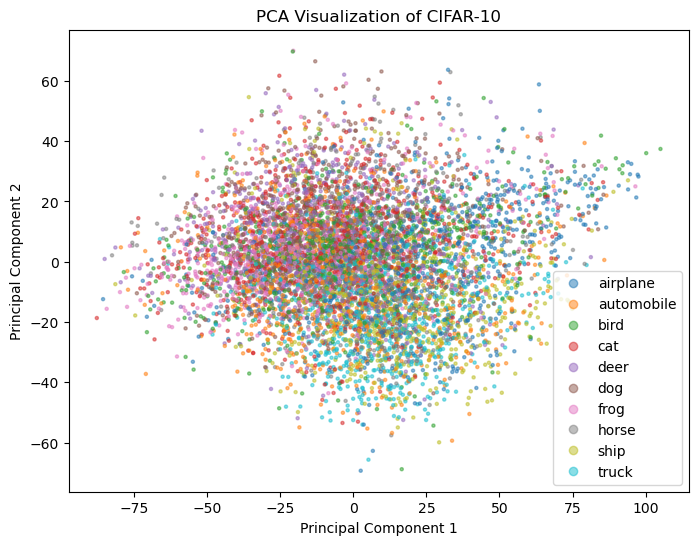

In [14]:
# PCA Process
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_subset)

plt.figure(figsize=(8, 6))

plot_PCA = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_subset, cmap='tab10', s=5, alpha=0.5)

plt.legend(handles=plot_PCA.legend_elements()[0], labels=class_names)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of CIFAR-10")

plt.show()

Here is a scatterplot of PCA dimension reduction, it looks like vehicle related items are split on the down side while animals related are toward the top side.

### LDA

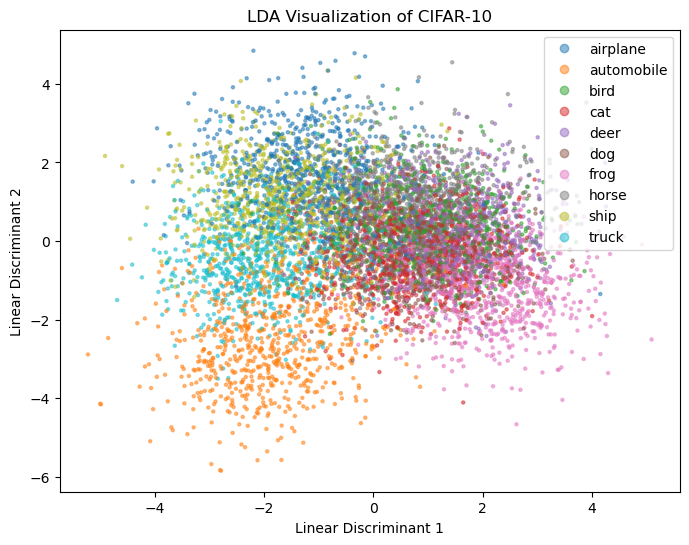

In [15]:
# LDA Process
lda = LinearDiscriminantAnalysis(n_components=2)

X_lda = lda.fit_transform(X_subset, y_subset) 

plt.figure(figsize=(8,6))

plot_LDA = plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y_subset, cmap='tab10', s=5, alpha=0.5)

plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.title("LDA Visualization of CIFAR-10")
plt.legend(handles=plot_LDA.legend_elements()[0], labels=class_names)

plt.show()

In this scatterplot looking at LDA it seems to vehicles are grouped to the left side while animals to the right.

### t-SNE

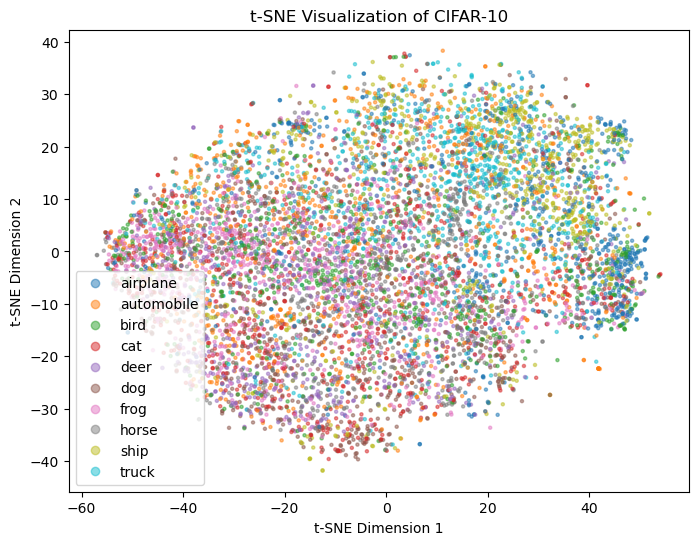

In [17]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_subset)  # No y needed — unsupervised like PCA

plt.figure(figsize=(8, 6))

plot_TSNE = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_subset, cmap='tab10', s=5, alpha=0.5)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Visualization of CIFAR-10")
plt.legend(handles=plot_TSNE.legend_elements()[0], labels=class_names)

plt.show()

Looking at t-SNE the group is more mixed up. It seems like deer, and automobiles is spread across, but generally the left is majority animals while right is vehicles.

### UMAP

c:\Users\kylec\anaconda3\envs\dse_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


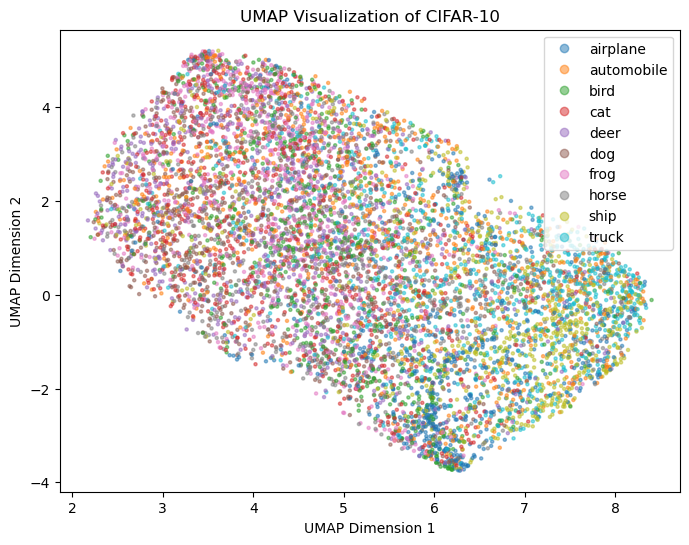

In [19]:
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_subset)  # Can optionally pass y for supervised UMAP

plt.figure(figsize=(8, 6))

plot_umap = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_subset, cmap='tab10', s=5, alpha=0.5)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Visualization of CIFAR-10")
plt.legend(handles=plot_umap.legend_elements()[0], labels=class_names)

plt.show()

The UMAP shows a more interesting distribution, but animals still seems more heavily on the top left while vehicles are on the bottom right. 

Dimensionality reduction techniques help visualize high-dimensional data by projecting it into two or three dimensions. This makes it easier to plot the data and see patterns, clusters, and how separated different groups are.